Assignment 09:  Use an AI-based tool to generate simple video animations.

Install Required Libraries

In [42]:
!pip install diffusers transformers accelerate torch moviepy imageio

Import Libraries

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
from moviepy.editor import ImageSequenceClip
from IPython.display import Video

Load the Model

Using Stable Diffusion from Hugging Face.

In [45]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Create Animation Prompts

In [46]:
prompts = [
    "cute robot standing in futuristic city",
    "cute robot walking in futuristic city",
    "cute robot waving hand in futuristic city",
    "cute robot jumping happily in futuristic city",
    "cute robot flying with jetpack in futuristic city"
]

In [ ]:
Generate Frames

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

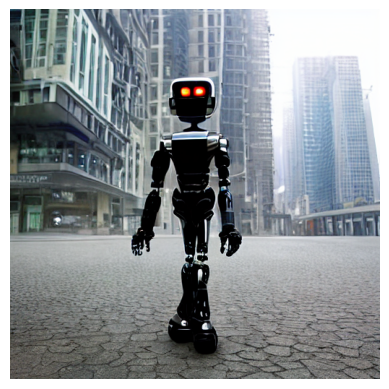

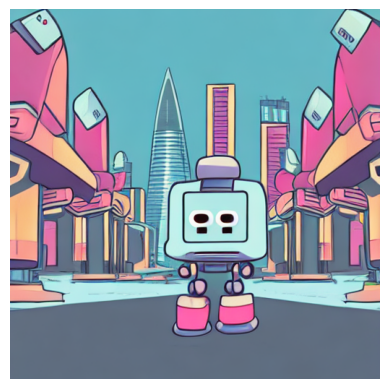

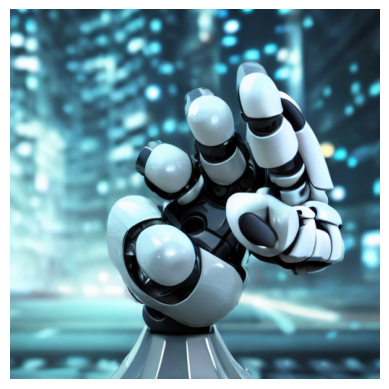

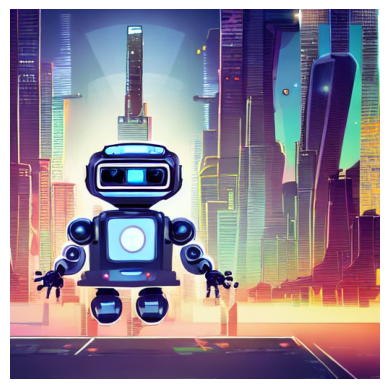

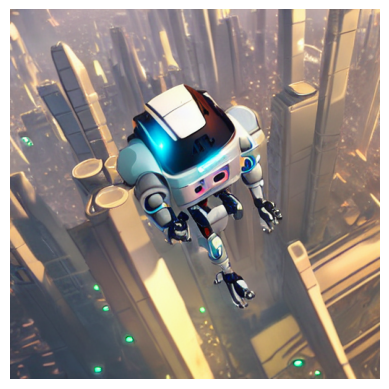

In [47]:
frames = []

for p in prompts:

    image = pipe(p).images[0]

    frames.append(np.array(image))

    plt.figure()
    plt.imshow(image)
    plt.axis("off")

Create Video Animation

In [48]:
clip = ImageSequenceClip(frames, fps=1)

clip.write_videofile("ai_animation.mp4")

Moviepy - Building video ai_animation.mp4.
Moviepy - Writing video ai_animation.mp4



Moviepy - Done !
Moviepy - video ready ai_animation.mp4


Display the Video

In [49]:
Video("ai_animation.mp4", embed=True)